# Exploratory Data Analysis: Singapore Museum Visitorship


## 0. Setup and Data Loading


In [220]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

sns.set_theme(style="whitegrid")

import sys
from pathlib import Path

In [221]:
# Repo root is one level up. Add repo root to sys.path so `config` and `src` are importable
sys.path.insert(0, str(Path.cwd().parent))

# Ensure changes to config and src are reflected in the notebook without restarting the kernel
import importlib
import config
import src.visualisation.eda
importlib.reload(config)
importlib.reload(src.visualisation.eda)
importlib.reload(src.features.data_prep)

from config import START_YEAR, START_MONTH, END_YEAR, END_MONTH, MUSEUM_CODES, COVID_START, COVID_END
from src.data.singstat_api import singstat_api
from src.features.data_prep import INTL_ARRIVALS_SERIES
from src.visualisation.eda import *
from src.visualisation.eda import get_shape, get_freq_dist

In [222]:
# Call the SingStat API to get the visitor and international arrivals
visitors = singstat_api("M891071", START_YEAR, START_MONTH, END_YEAR, END_MONTH)
intl_arrivals = singstat_api("M550001", START_YEAR, START_MONTH, END_YEAR, END_MONTH)

In [223]:
print("visitors shape:", get_shape(visitors))
print("intl_arrivals shape:", get_shape(intl_arrivals))

visitors shape: (1,898 rows, 3 cols)
intl_arrivals shape: (9,114 rows, 3 cols)


In [224]:
visitors.head()

,Data Series,Reporting Period,Value
0,Asian Civilisations Museum,2014 Jan,36.5
1,Asian Civilisations Museum,2014 Feb,37.7
2,Asian Civilisations Museum,2014 Mar,49.4
3,Asian Civilisations Museum,2014 Apr,46.5
4,Asian Civilisations Museum,2014 May,38.6


In [225]:
intl_arrivals.head()

,Data Series,Reporting Period,Value
0,Total International Visitor Arrivals By Place ...,2014 Jan,1345842
1,Total International Visitor Arrivals By Place ...,2014 Feb,1238239
2,Total International Visitor Arrivals By Place ...,2014 Mar,1297551
3,Total International Visitor Arrivals By Place ...,2014 Apr,1245307
4,Total International Visitor Arrivals By Place ...,2014 May,1208532


In [226]:
# Tidy the raw API output into a monthly, numeric, long-format frame for EDA.
def tidy_df(df):
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["Reporting Period"], format="%Y %b")
    df["value"] = pd.to_numeric(df["Value"], errors="coerce").fillna(
        0
    )  # missing (e.g. "na", "-") -> 0
    return df.sort_values(["Data Series", "timestamp"]).reset_index(drop=True)


# The selected museums, tagged with their short codes.
museums = tidy_df(visitors)
museums = museums[museums["Data Series"].isin(MUSEUM_CODES)].copy()
museums["code"] = museums["Data Series"].map(MUSEUM_CODES)

# Total international arrivals only
intl_arrivals_total = tidy_df(intl_arrivals)
intl_arrivals_total = intl_arrivals_total[
    intl_arrivals_total["Data Series"] == INTL_ARRIVALS_SERIES
].copy()

museums[["code", "timestamp", "value"]].head()

,code,timestamp,value
0,ACM,2014-01-01,36.5
1,ACM,2014-02-01,37.7
2,ACM,2014-03-01,49.4
3,ACM,2014-04-01,46.5
4,ACM,2014-05-01,38.6


## 1. Data Quality and Integrity


In [227]:
# Per-museum coverage & completeness: date span, months present, and counts of
# truly-missing months, NaNs, and zeros (closures show up as zeros/missing).
full_idx = pd.date_range(
    museums["timestamp"].min(), museums["timestamp"].max(), freq="MS"
)

rows = []
for code, g in museums.groupby("code"):
    rows.append(
        {
            "code": code,
            "start": g["timestamp"].min().strftime("%Y-%m"),
            "end": g["timestamp"].max().strftime("%Y-%m"),
            "n_months": len(g),
            "missing_months": len(
                full_idx.difference(pd.DatetimeIndex(g["timestamp"]))
            ),
            "n_nan": int(g["value"].isna().sum()),
            "n_zero": int((g["value"] == 0).sum()),
        }
    )

coverage = pd.DataFrame(rows).set_index("code")
print(
    f"Full monthly index spans {len(full_idx)} months: "
    f"{full_idx.min():%Y-%m} to {full_idx.max():%Y-%m}"
)
coverage

Full monthly index spans 147 months: 2014-01 to 2026-03


,start,end,n_months,missing_months,n_nan,n_zero
code,,,,,,
ACM,2014-01,2026-03,147,0,0,1
IHC,2015-05,2026-03,131,16,0,2
MHC,2014-01,2025-11,143,4,0,39
NMS,2014-01,2026-03,147,0,0,1
TPM,2014-01,2026-03,147,0,0,46


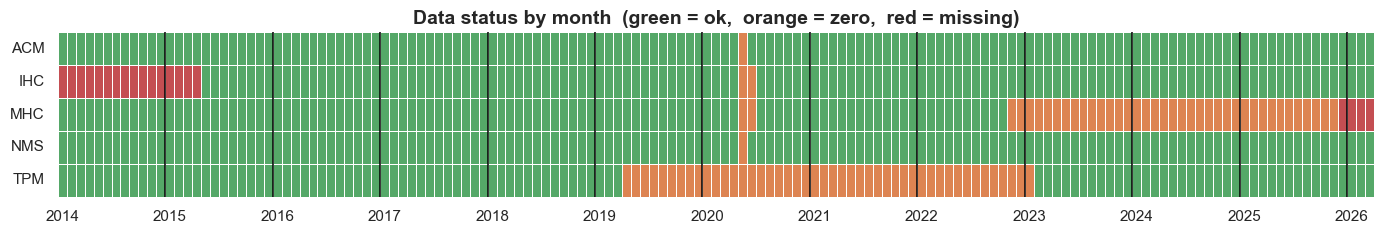

In [228]:
from matplotlib.colors import ListedColormap

# Pivot to a museum x month grid of values
pivot = museums.pivot_table(
    index="code",
    columns=museums["timestamp"].dt.strftime("%Y-%m"),
    values="value",
)

# Classify each cell: 0 = ok, 1 = zero, 2 = missing
status = pd.DataFrame(0, index=pivot.index, columns=pivot.columns)
status[pivot == 0] = 1
status[pivot.isna()] = 2

# Heatmap with white borders around every monthly cell
fig, ax = plt.subplots(figsize=(14, 2.5))
sns.heatmap(
    status,
    ax=ax,
    cbar=False,
    vmin=0,
    vmax=2,
    cmap=ListedColormap(["#55a868", "#dd8452", "#c44e52"]),  # green / orange / red
    linewidths=0.5,
    linecolor="white",
)

# Bold title
title = ax.set_title(
    "Data status by month  (green = ok,  orange = zero,  red = missing)",
    fontweight="bold",
)
title.set_fontsize(title.get_fontsize() + 2)

# Remove axis labels
ax.set_xlabel("")
ax.set_ylabel("")

# X-axis: tick + label only January of each year (labelled with the year)
jan = [(i, col[:4]) for i, col in enumerate(status.columns) if col.endswith("-01")]
ax.set_xticks([i + 0.5 for i, _ in jan])
ax.set_xticklabels([year for _, year in jan], rotation=0)

# Thick vertical lines at each year boundary (each January)
for i, _ in jan:
    if i > 0:
        ax.axvline(i, color="black", linewidth=1.1)

# Y-axis: keep museum labels horizontal
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 2. Univariate Analysis


### Target: `value` (Monthly Visitorship by Museum)


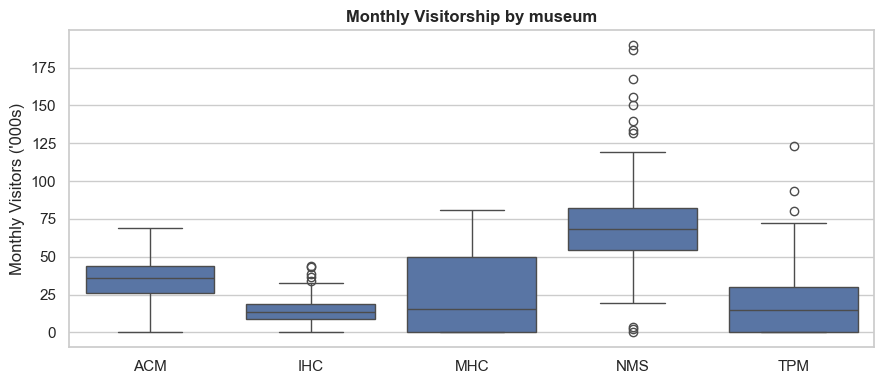

In [229]:
# Spread & outliers of monthly visitorship by museum.
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=museums, x="code", y="value", ax=ax)
ax.set_title("Monthly Visitorship by museum", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Monthly Visitors ('000s)")
plt.tight_layout()
plt.show()

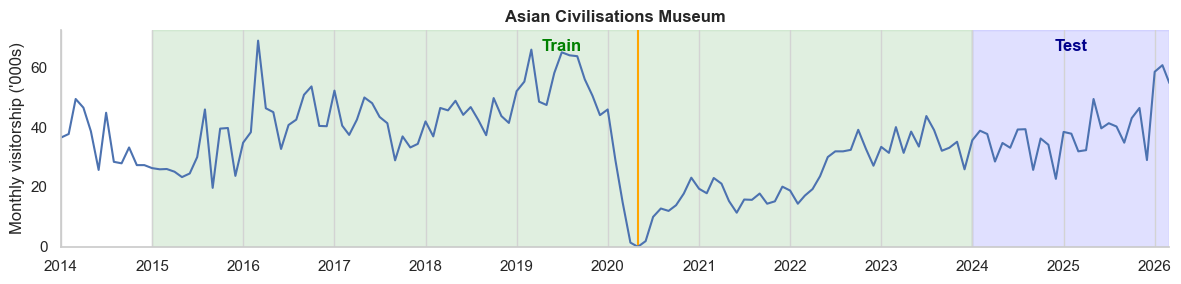

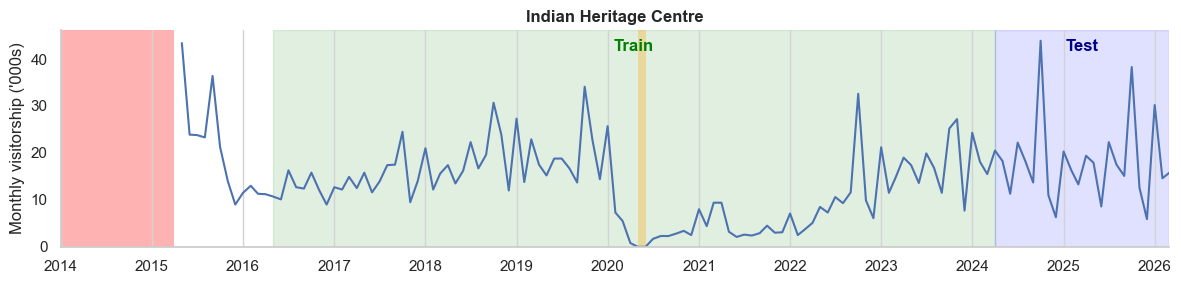

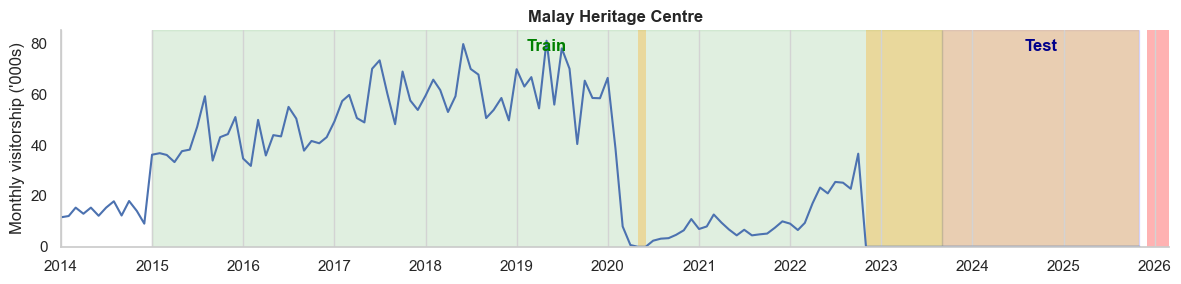

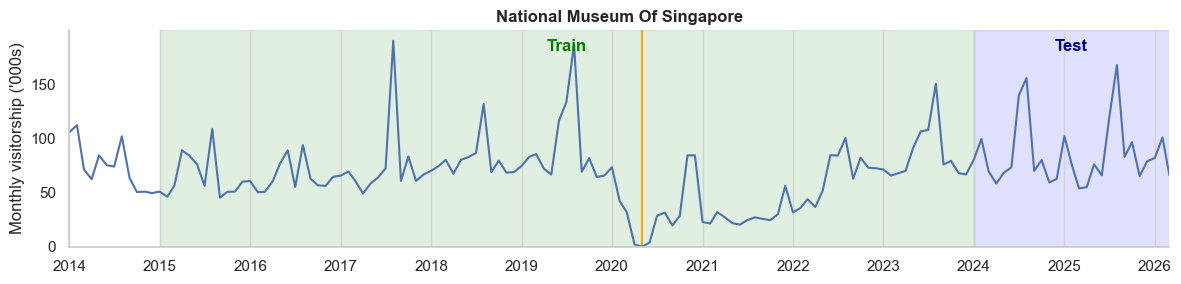

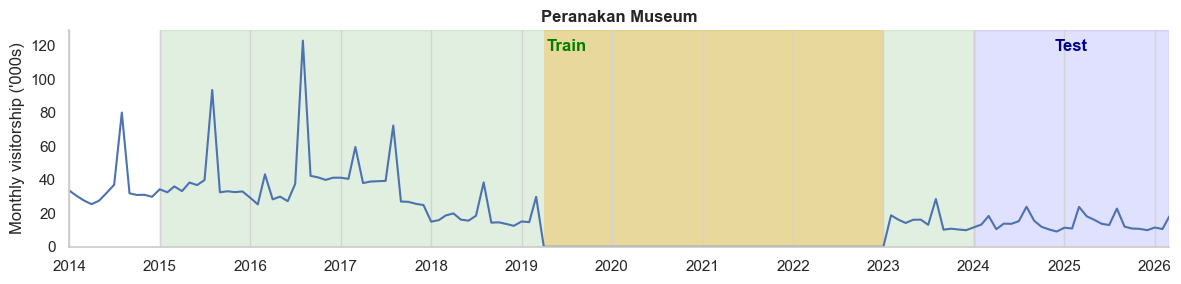

In [230]:
# One monthly-visitorship time series per museum (5 separate plots, shared x range).
from src.features.data_prep import prepare_eval_data

xmin, xmax = museums["timestamp"].min(), museums["timestamp"].max()
for name, group in museums.groupby("Data Series"):
    # Train/test boundaries from the pipeline's own 80/20 split (see prepare_eval_data)
    train_data, test_data, _ = prepare_eval_data(
        visitors[visitors["Data Series"] == name], intl_arrivals
    )
    train_test = (
        train_data["timestamp"].min(),
        test_data["timestamp"].min(),
        test_data["timestamp"].max(),
    )
    plot_monthly_visitorship(
        group, title=name, xmin=xmin, xmax=xmax, train_test=train_test
    )

### `intl_arrivals` (Jan 2014 - Mar 2026)


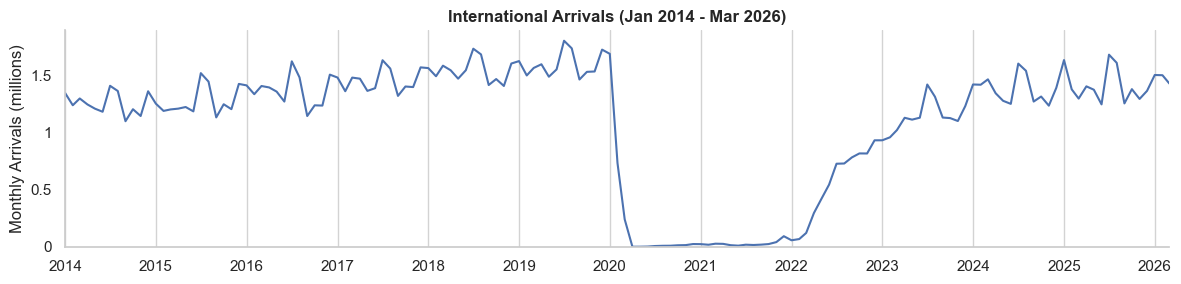

In [231]:
# Monthly international visitor arrivals (the exogenous feature, shared x range).
plot_monthly_visitorship(
    intl_arrivals_total,
    title=f"International Arrivals ({START_MONTH} {START_YEAR} - {END_MONTH} {END_YEAR})",
    xmin=xmin,
    xmax=xmax,
    ylabel="Monthly Arrivals (millions)",
    highlight_missing=True,
    y_millions=True,
)

### `is_covid`

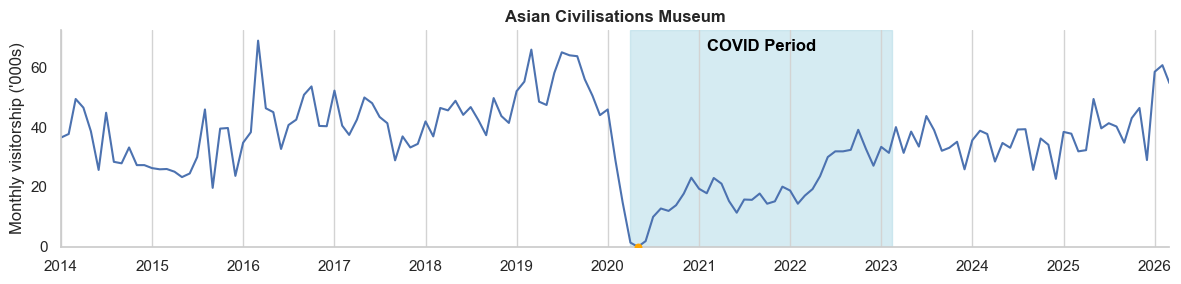

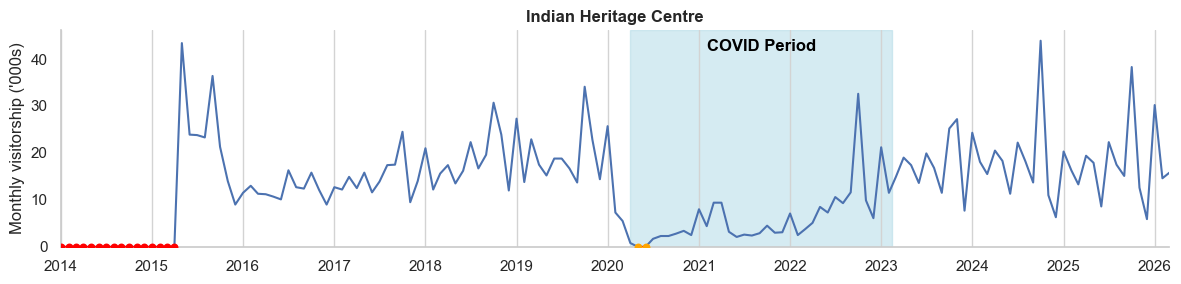

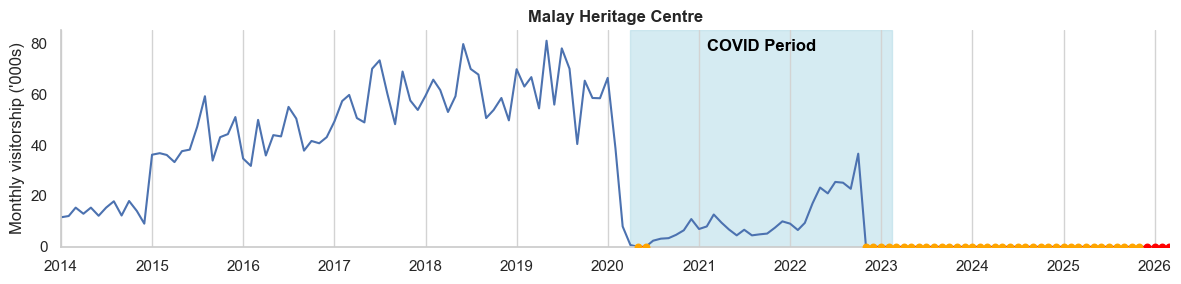

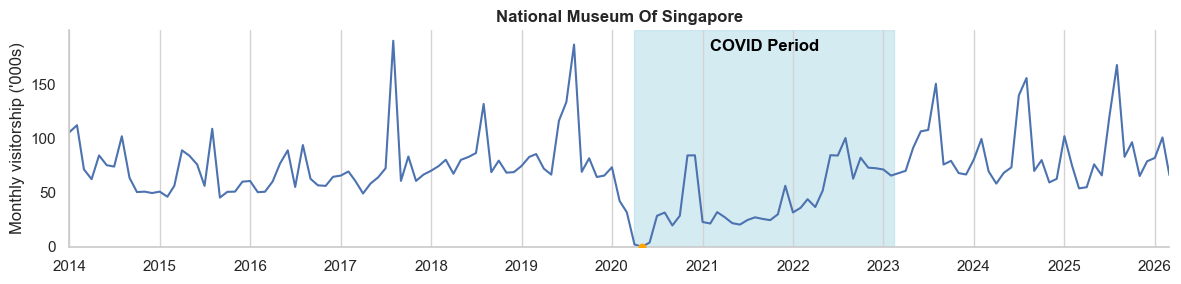

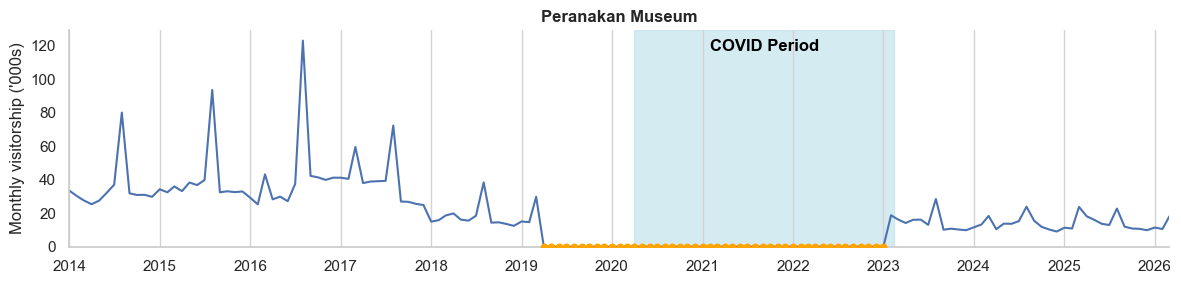

In [232]:
# Monthly visitorship per museum against the COVID period (shared x range).
for name, group in museums.groupby("Data Series"):
    plot_covid_period(
        group,
        title=name,
        xmin=xmin,
        xmax=xmax,
        covid_start=COVID_START,
        covid_end=COVID_END,
    )

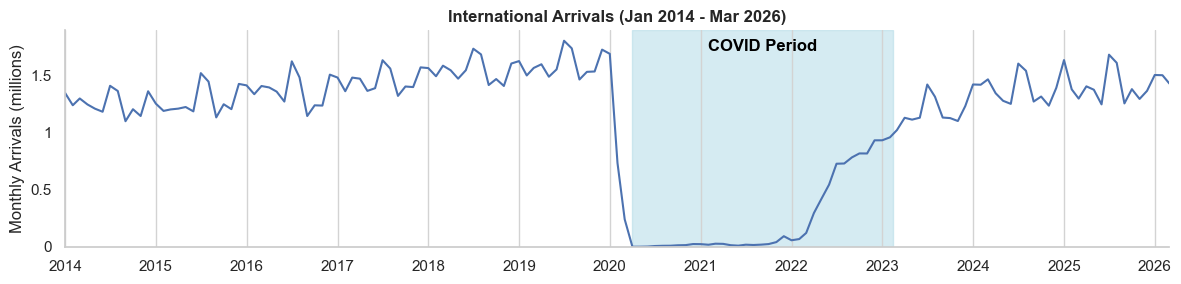

In [233]:
# Monthly international visitor arrivals against the COVID period.
plot_covid_period(
    intl_arrivals_total,
    title=f"International Arrivals ({START_MONTH} {START_YEAR} - {END_MONTH} {END_YEAR})",
    xmin=xmin,
    xmax=xmax,
    covid_start=COVID_START,
    covid_end=COVID_END,
    ylabel="Monthly Arrivals (millions)",
    y_millions=True,
)

## 3. Bivariate Analysis


Mean Museum Visitorship by Month by Museum

## 4. Temporal Structure


### Tests for Stationarity

### Differencing

### ACF and PACF Plots
For determining `d` and `D` for SARIMAX

## 5. Anomalies and Special Cases


### Investigate each museum's seasonal peaks


ACM

IHC

MHC

NMS

TPM

## 6. Analysis of Effects of Various Methods of Imputation of Future Feature Values for Forecasting Museum Visitorship

Background:
- This section aims to study the effects of certain decisions made by the team who wrote the old code
    - future unknown values for lag features were imputed by historical (2014-2026) monthly means
    - they did not replicate the imputation for test set, instead simply using known lag feature values (which does not reflect real predictions)
- Additionally, we will study which method is best for imputing future values for a new feature: `intl_arrivals`

<hr>

Visitorship by Museum (Jan 2014 - Mar 2026 - Mar 2028)

In [234]:
# ACM with imputed future lag features (Jan 2014 - Mar 2026 - Mar 2028)
# future lag features are imputed with full period historical monthly mean

In [235]:
# With imputed future lag features (Jan 2014 - Mar 2026 - Mar 2028)
# future lag features are imputed with past 3-year historical monthly mean

In [236]:
# IHC with imputed future lag features (Jan 2014 - Mar 2026 - Mar 2028)
# future lag features are imputed with full period historical monthly mean

In [237]:
# With imputed future lag features (Jan 2014 - Mar 2026 - Mar 2028)
# future lag features are imputed with past 3-year historical monthly mean

In [238]:
# MHC with imputed future lag features (Jan 2014 - Mar 2026 - Mar 2028)
# future lag features are imputed with full period historical monthly mean

In [239]:
# With imputed future lag features (Jan 2014 - Mar 2026 - Mar 2028)
# future lag features are imputed with past 3-year historical monthly mean

In [240]:
# NMS with imputed future lag features (Jan 2014 - Mar 2026 - Mar 2028)
# future lag features are imputed with full period historical monthly mean

In [241]:
# With imputed future lag features (Jan 2014 - Mar 2026 - Mar 2028)
# future lag features are imputed with past 3-year historical monthly mean

In [242]:
# TPM with imputed future lag features (Jan 2014 - Mar 2026 - Mar 2028)
# future lag features are imputed with full period historical monthly mean

In [243]:
# With imputed future lag features (Jan 2014 - Mar 2026 - Mar 2028)
# future lag features are imputed with past 3-year historical monthly mean

Total Museum Visitorship

In [244]:
# Total Museum Visitorship (Jan 2014 - Mar 2026)

International Arrivals (Jan 2014 - Mar 2026)

In [245]:
# With imputed future intl_arrivals (Jan 2014 - Mar 2026 - Mar 2028)
# future intl_arrivals are imputed with full period historical monthly mean

In [246]:
# With imputed future intl_arrivals (Jan 2014 - Mar 2026 - Mar 2028)
# future intl_arrivals are imputed with past 3-year historical monthly mean

### Investigating effect of imputing future lag features and international arrivals

Visitorship by Museum (Jan 2014 - Mar 2026)

International Arrivals (Jan 2014 - Mar 2026)